In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pandas.plotting import scatter_matrix
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

base_dir = Path.cwd()

housing_csv = base_dir / "portland_housing.csv"
overdose_csv = base_dir / "VSRR_Provisional_Drug_Overdose_Death_Counts_20260218.csv"

processed_dir = base_dir / "data" / "02-processed"
processed_dir.mkdir(parents=True, exist_ok=True)

final_csv = processed_dir / "monthly_housing_overdose_2020_2021.csv"

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

* [ x ] YES - make available
* [  ] NO - keep private

## Link to video
https://youtu.be/XpUjZcXMz9w

# Do Housing Prices Track Overdose Deaths? Evidence from Portland Housing Estimates and Oregon Mortality Data, 2020–2021


## Abstract

This project examines whether monthly housing prices in the Portland metropolitan area were associated with monthly opioid overdose deaths and total drug overdose deaths in Oregon during 2020–2021. To do this, we merged monthly average Zillow Zestimate data with CDC provisional overdose mortality data and conducted an exploratory time-series analysis. Our analysis included trend visualization, pairwise correlations, lagged correlations, and simple regressions that adjusted for a linear time trend.

At the descriptive level, housing prices and overdose mortality appeared to move upward together over parts of the study period, producing modest positive raw correlations. However, once basic time structure was taken into account, the association between housing prices and overdose deaths became weak or disappeared, suggesting that the initial relationship was largely driven by shared temporal trends rather than a stable direct association. Lagged correlations also varied across month shifts and did not reveal a consistent pattern.

Overall, we do not find strong evidence of a stable relationship between housing prices and overdose mortality in this dataset. These findings should be interpreted cautiously: the study uses a short time window, aggregated public data, and  many important confounders remain unobserved. As a result, this project is best understood as an exploratory descriptive analysis rather than a causal study.

## Authors

- Daniel Fichthorn: Conceptualization, Methodology, Project administration, Writing - review & editing
- Zilong Feng: Software, Data curation, Analysis, Visualization
- Evan Asti: Background research, Experimental investigation, Writing - original draft, Visualization
- Mulan Zhou: Data curation, Analysis, Methodology, Writing - original draft
- Saidazim Saidov: Software, Analysis, Visualization, Writing - review & editing

## Research Question

This study aims to examine whether monthly housing prices in the Portland metropolitan area were associated with monthly opioid overdose deaths and total drug overdose deaths in Oregon during 2020–2021. Specifically, we analyze whether changes in the monthly average Zestimate moved together with changes in overdose mortality over the same period. Through exploratory data analysis, correlation analysis, and time-adjusted regression, we assess the strength, direction, and stability of this relationship, including whether it persists after accounting for basic time trends.

## Background and Prior Work

Drug overdose mortality in the United States is shaped not only by drug supply and individual behavior, but also by broader social and economic conditions. A recent systematic review of U.S. spatial studies found that area-level socioeconomic conditions—such as employment, income, and poverty-related measures—were moderately and consistently associated with overdose death rates across many study designs and geographic units (Fink et al., 2024). This suggests that overdose patterns are embedded in larger community conditions rather than being explained only at the individual level. In that context, housing-related stress is especially relevant, because housing affordability, instability, and neighborhood change can reflect wider economic pressure experienced by residents.

Prior empirical work also suggests that housing-related hardship may be linked to overdose risk. At the community level, Bradford and Bradford found that higher county eviction rates were associated with higher accidental drug- and alcohol-related mortality, including opioid mortality, in the United States (Bradford & Bradford, 2020). At the state level, Cano and Oh reported that higher homelessness prevalence was positively associated with overdose mortality even after adjusting for nationwide trends, state fixed effects, demographic composition, and unemployment (Cano & Oh, 2023). At the individual level, Yamamoto and colleagues found that homeless individuals had substantially higher adjusted risk of opioid overdose than low-income housed individuals treated at the same hospital (Yamamoto et al., 2019). Taken together, these studies do not prove that housing conditions directly cause overdose deaths, but they do support the broader idea that housing insecurity and related economic strain may co-occur with elevated overdose risk.

Our project builds on that literature in a narrower and more exploratory way. Instead of estimating the effect of eviction, homelessness, or a formal affordability index, we examine whether monthly housing values in the Portland metropolitan area moved together with monthly opioid overdose deaths and total drug overdose deaths in Oregon during 2020–2021. We use Zillow’s Zestimate as a housing-market indicator; Zillow describes the Zestimate as a model-based estimate of a home’s market value constructed from public, MLS, user-submitted, and market-trend information, rather than a formal appraisal . We pair this with CDC provisional overdose data, which are useful for monitoring recent trends but are also subject to incompleteness, reporting delays, revisions, and cross-jurisdiction differences in specific-drug reporting . For that reason, our study is best understood as a descriptive time-series comparison rather than a causal analysis. Its main contribution is to align two public datasets at a monthly scale and test whether any apparent association remains once basic time structure is taken into account.

## Hypothesis


We expected monthly housing prices in the Portland metropolitan area to show some positive association with monthly opioid overdose deaths and total drug overdose deaths in Oregon during 2020–2021. In particular, we expected months with higher housing prices to be associated with higher overdose mortality, although we also expected this relationship to weaken after accounting for time trends and other unobserved factors. We further explored whether any association would appear more strongly at short time lags rather than in the same month.

## Data

### Data overview

This project uses two public datasets: a housing dataset for the Portland metropolitan area and a drug overdose mortality dataset for Oregon.

The housing dataset was compiled from Zillow and contains 25,731 property-level observations from the Portland area. It includes variables such as city, ZIP code, number of bedrooms, number of bathrooms, days on Zillow, sale date, and Zestimate. For this project, we focused on the variables most relevant to our research question: the sale date and Zestimate, along with a small set of basic housing descriptors used during cleaning and quality checks. Because the housing data were recorded at the property level, we converted sale dates into year-month values and then aggregated the data to the monthly level by calculating the monthly average Zestimate. This gave us a single housing-market measure for each month in the available period.

The overdose dataset comes from the CDC Provisional Drug Overdose Death Counts release and was filtered to observations for Oregon only. From this dataset, we selected two indicators: Opioids (T40.0–T40.4, T40.6) and Number of Drug Overdose Deaths. The original data are reported by month, so after filtering to the years 2020–2021, we grouped the data by year and month and created two monthly outcome variables: opioid_deaths and overdose_deaths. This produced a monthly time series of overdose mortality measures that could be aligned with the housing data.

After cleaning both datasets, we merged them by year_month to create a single monthly analysis dataset. The final merged dataset contains one row per month and includes three main variables used in our analysis: housing_zestimate_mean, opioid_deaths, and overdose_deaths. This structure allowed us to compare changes in housing prices and overdose deaths over time using visualizations, correlations, lagged correlations, and simple regression models.

### Dataset #1 


In [25]:
housing = pd.read_csv(housing_csv, low_memory=False)

keep_cols = [
    "address/city",
    "address/zipcode",
    "bedrooms",
    "bathrooms",
    "daysOnZillow",
    "dateSold",
    "zestimate",
]

housing = housing[keep_cols].copy()
housing.head()

,address/city,address/zipcode,bedrooms,bathrooms,daysOnZillow,dateSold,zestimate
0,Fairview,97024,3.0,3.0,25.0,1.621560e+12,317406.0
1,Fairview,97024,3.0,3.0,53.0,1.619140e+12,NaN
2,Gresham,97080,4.0,3.0,11.0,1.622760e+12,512355.0
3,Portland,97230,3.0,1.0,11.0,1.622760e+12,NaN
4,Gresham,97030,6.0,3.0,14.0,1.622510e+12,NaN


In [26]:
housing["dateSold"] = pd.to_datetime(
    housing["dateSold"],
    unit="ms",
    errors="coerce"
)

housing = housing.dropna(subset=["dateSold"])
housing["year"] = housing["dateSold"].dt.year
housing["month"] = housing["dateSold"].dt.month
housing["year_month"] = housing["dateSold"].dt.to_period("M").astype(str)

housing = housing[(housing["year"] >= 2020) & (housing["year"] <= 2021)].copy()

housing[["dateSold", "year", "month", "year_month"]].head()

housing_monthly = (
    housing.groupby("year_month", as_index=False)["zestimate"]
    .mean()
    .rename(columns={"zestimate": "housing_zestimate_mean"})
)

housing_monthly.head()

,year_month,housing_zestimate_mean
0,2020-06,465753.666667
1,2020-07,653614.510478
2,2020-08,657457.913413
3,2020-09,653510.883099
4,2020-10,629304.356298


### Dataset #2 

In [27]:
overdose = pd.read_csv(overdose_csv, low_memory=False)
overdose.columns = [c.strip().lower() for c in overdose.columns]

overdose["state"] = overdose["state"].astype(str).str.strip().str.lower()
overdose = overdose[overdose["state"] == "or"].copy()

overdose["indicator"] = overdose["indicator"].astype(str).str.strip()

overdose["year"] = pd.to_numeric(overdose["year"], errors="coerce")
overdose = overdose.dropna(subset=["year"])
overdose["year"] = overdose["year"].astype(int)

overdose.head()

,state,year,month,period,indicator,data value,percent complete,percent pending investigation,state name,footnote,footnote symbol,predicted value
56115,or,2015,January,12 month-ending,Cocaine (T40.5),20,100,0.023248,Oregon,Numbers may differ from published reports usin...,**,20
56116,or,2015,February,12 month-ending,Cocaine (T40.5),19,100,0.023091,Oregon,Numbers may differ from published reports usin...,**,19
56117,or,2015,March,12 month-ending,Cocaine (T40.5),18,100,0.023006,Oregon,Numbers may differ from published reports usin...,**,18
56118,or,2015,April,12 month-ending,Cocaine (T40.5),18,100,0.020047,Oregon,Numbers may differ from published reports usin...,**,18
56119,or,2015,May,12 month-ending,Cocaine (T40.5),14,100,0.019910,Oregon,Numbers may differ from published reports usin...,**,14


In [28]:
date1 = pd.to_datetime(
    overdose["year"].astype(str) + "-" + overdose["month"].astype(str),
    format="%Y-%B",
    errors="coerce"
)

date2 = pd.to_datetime(
    overdose["year"].astype(str) + "-" + overdose["month"].astype(str),
    format="%Y-%b",
    errors="coerce"
)

overdose["date"] = date1.fillna(date2)
overdose = overdose.dropna(subset=["date"])

overdose["year_month"] = overdose["date"].dt.to_period("M").astype(str)
overdose["data value"] = pd.to_numeric(overdose["data value"], errors="coerce")

overdose = overdose[
    (overdose["date"] >= "2020-01-01") &
    (overdose["date"] <= "2021-12-31")
].copy()

overdose[["date", "year_month", "indicator", "data value"]].head()

,date,year_month,indicator,data value
56175,2020-01-01,2020-01,Cocaine (T40.5),63.0
56176,2020-02-01,2020-02,Cocaine (T40.5),66.0
56177,2020-03-01,2020-03,Cocaine (T40.5),62.0
56178,2020-04-01,2020-04,Cocaine (T40.5),57.0
56179,2020-05-01,2020-05,Cocaine (T40.5),69.0


In [29]:
opioid_key = "Opioids (T40.0-T40.4,T40.6)"
total_key = "Number of Drug Overdose Deaths"

opioid_monthly = (
    overdose[overdose["indicator"] == opioid_key]
    .groupby("year_month", as_index=False)["data value"]
    .sum(min_count=1)
    .rename(columns={"data value": "opioid_deaths"})
)

total_monthly = (
    overdose[overdose["indicator"] == total_key]
    .groupby("year_month", as_index=False)["data value"]
    .sum(min_count=1)
    .rename(columns={"data value": "overdose_deaths"})
)

opioid_monthly.head(), total_monthly.head()

(  year_month  opioid_deaths
 0    2020-01          339.0
 1    2020-02          341.0
 2    2020-03          346.0
 3    2020-04          351.0
 4    2020-05          397.0,
   year_month  overdose_deaths
 0    2020-01            621.0
 1    2020-02            624.0
 2    2020-03            633.0
 3    2020-04            644.0
 4    2020-05            701.0)

In [30]:
df = housing_monthly.merge(opioid_monthly, on="year_month", how="inner")
df = df.merge(total_monthly, on="year_month", how="inner")

df["year_month"] = pd.to_datetime(df["year_month"])
df = df.sort_values("year_month").reset_index(drop=True)

df.to_csv(final_csv, index=False)

print("Final dataset saved to:", final_csv)
df.head()

Final dataset saved to: C:\Users\23395\data\02-processed\monthly_housing_overdose_2020_2021.csv


,year_month,housing_zestimate_mean,opioid_deaths,overdose_deaths
0,2020-06-01,465753.666667,407.0,701.0
1,2020-07-01,653614.510478,420.0,715.0
2,2020-08-01,657457.913413,437.0,734.0
3,2020-09-01,653510.883099,443.0,745.0
4,2020-10-01,629304.356298,467.0,763.0


In [31]:
print("Shape:", df.shape)
print("Date range:", df["year_month"].min(), "to", df["year_month"].max())
print()
print(df.describe())
df.isnull().sum()

Shape: (14, 4)
Date range: 2020-06-01 00:00:00 to 2021-07-01 00:00:00

       housing_zestimate_mean  opioid_deaths  overdose_deaths
count               14.000000      14.000000        12.000000
mean            630491.267557     520.428571       810.333333
std              48803.752712      85.341589        85.556290
min             465753.666667     407.000000       701.000000
25%             633362.582454     449.000000       742.250000
50%             644186.421491     506.500000       792.000000
75%             652712.536938     588.000000       869.250000
max             657457.913413     671.000000       951.000000


year_month                0
housing_zestimate_mean    0
opioid_deaths             0
overdose_deaths           2
dtype: int64

## Results

### Exploratory Data Analysis

We began with an exploratory analysis of the merged monthly dataset. This step was intended to verify the time alignment of the two data sources and to better understand the basic patterns in the data before fitting regression models.

The monthly time-series plots show that housing prices, opioid overdose deaths, and total overdose deaths all changed over the study period. Housing prices generally increased over time, while the mortality variables also showed noticeable upward movement during part of the same period. This shared upward movement suggests that the variables may be positively associated at the descriptive level, but visual co-movement alone is not enough to establish a stable relationship.

To further examine the data, we calculated pairwise correlations among the three main variables. The correlation between monthly housing prices and opioid overdose deaths was positive but modest, and the correlation between housing prices and total overdose deaths was similarly modest. By contrast, opioid deaths and total overdose deaths were extremely strongly correlated, which is expected because opioid deaths are a major subset of total drug overdose deaths.

Overall, the exploratory analysis suggests that housing prices and overdose mortality may move together in a broad descriptive sense, but it also raises an important concern: because all three series change over time, any raw association may partly reflect shared temporal trends rather than a direct relationship. This issue motivates the more focused analyses that follow.

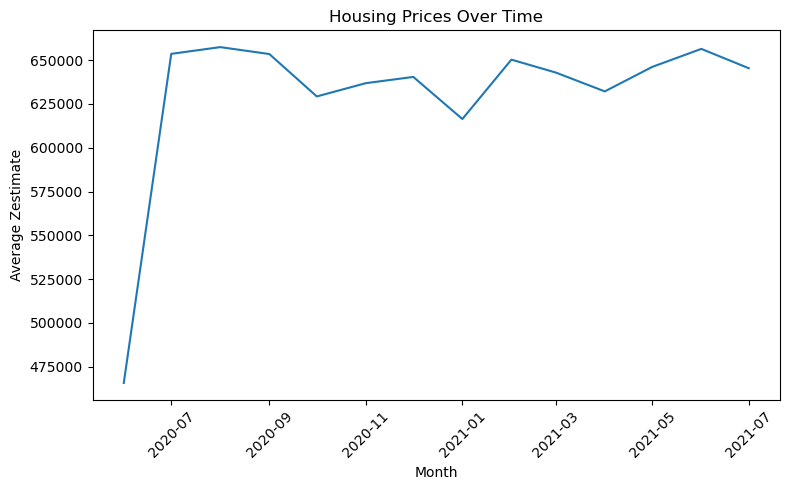

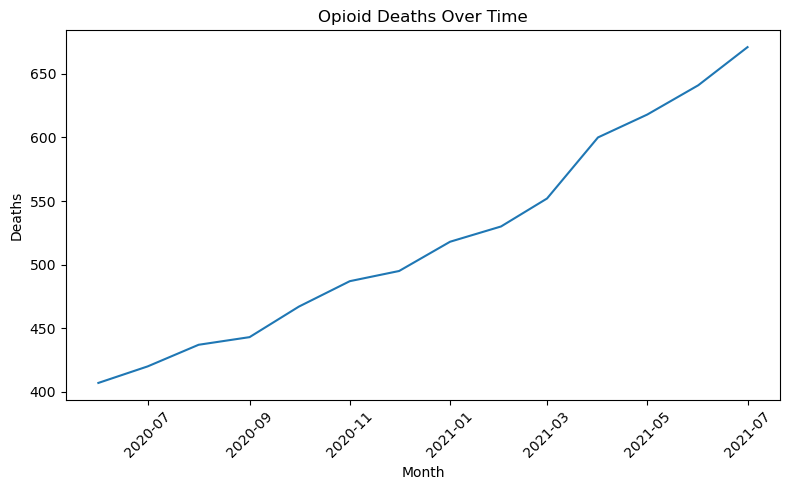

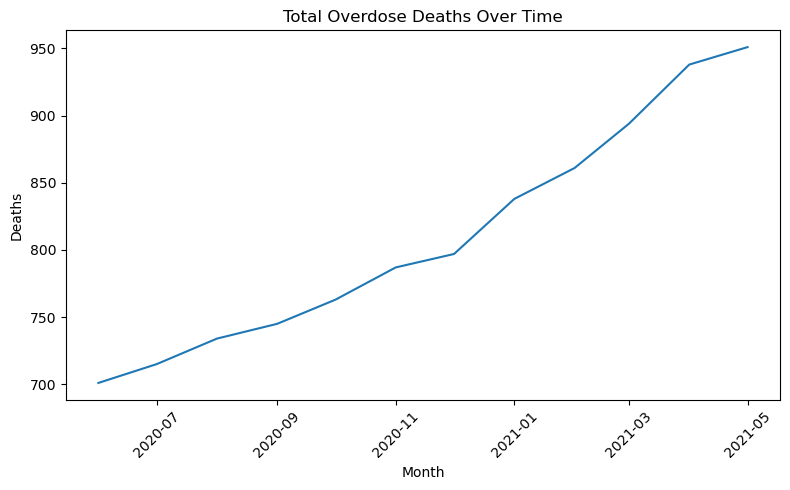

In [32]:
plt.figure()
plt.plot(df["year_month"], df["housing_zestimate_mean"])
plt.title("Housing Prices Over Time")
plt.xlabel("Month")
plt.ylabel("Average Zestimate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df["year_month"], df["opioid_deaths"])
plt.title("Opioid Deaths Over Time")
plt.xlabel("Month")
plt.ylabel("Deaths")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df["year_month"], df["overdose_deaths"])
plt.title("Total Overdose Deaths Over Time")
plt.xlabel("Month")
plt.ylabel("Deaths")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The following figure shows the standardized trends of housing prices, opioid deaths, and total overdose deaths on the same scale. The two mortality measures show a clearer upward trend and move closely together over time, while housing prices rise more moderately and less consistently. This suggests some descriptive co-movement, but the relationship is not stable.

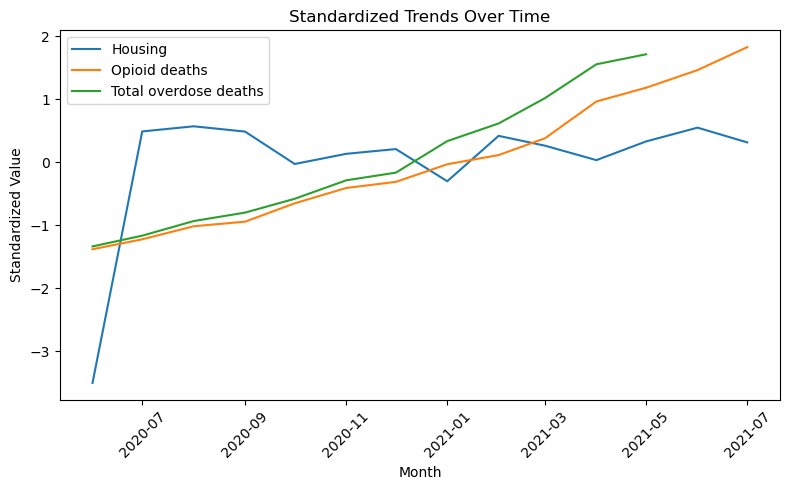

In [33]:
def zscore(x):
    return (x - x.mean()) / x.std(ddof=0)

df["z_housing"] = zscore(df["housing_zestimate_mean"])
df["z_opioid"] = zscore(df["opioid_deaths"])
df["z_overdose"] = zscore(df["overdose_deaths"])

plt.figure()
plt.plot(df["year_month"], df["z_housing"], label="Housing")
plt.plot(df["year_month"], df["z_opioid"], label="Opioid deaths")
plt.plot(df["year_month"], df["z_overdose"], label="Total overdose deaths")
plt.title("Standardized Trends Over Time")
plt.xlabel("Month")
plt.ylabel("Standardized Value")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Next, we plotted a scatter matrix to further examine the distributions and pairwise relationships among housing prices, opioid deaths, and total overdose deaths. The figure shows a very strong positive relationship between opioid deaths and total overdose deaths, while housing prices have only a weak to moderate positive relationship with both mortality measures.

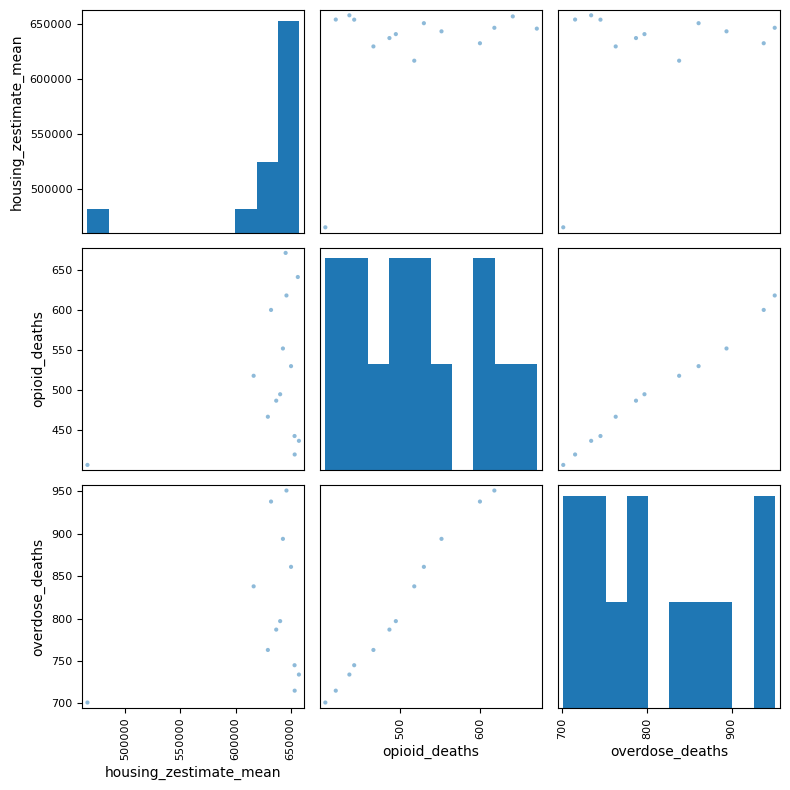

In [34]:
scatter_matrix(
    df[["housing_zestimate_mean", "opioid_deaths", "overdose_deaths"]],
    figsize=(8, 8),
    diagonal="hist"
)
plt.tight_layout()
plt.show()

### Analysis 1: Association and Lagged Correlations Between Housing Prices and Overdose Deaths

In this section, we examined both contemporaneous and lagged correlations between housing prices and overdose mortality. We first calculated Pearson correlations using the merged monthly dataset to see whether housing prices were related to the two mortality measures within the same month. The results showed a weak to moderate positive correlation between housing prices and both opioid deaths and total overdose deaths. In other words, months with higher housing prices also tended to have somewhat higher overdose death counts. However, this relationship was much weaker than the correlation between opioid deaths and total overdose deaths, which was nearly perfect, as expected, because opioid deaths are a major subset of total overdose deaths.

We then extended the analysis by shifting housing prices backward and forward by up to three months to examine whether the correlation changed across short time lags. Here, a positive lag means that earlier housing prices are compared with later overdose deaths, while a negative lag means that later housing prices are compared with earlier overdose deaths. The results showed that the correlations changed across month shifts: the contemporaneous correlations were positive, the positive lags were slightly stronger, and the negative lags were weaker and sometimes negative. However, the pattern was not clear or stable enough to suggest one consistent lag structure.

Overall, this analysis suggests that housing prices and overdose mortality show some descriptive co-movement.

In [35]:
def lag_corr(x, y, lag):
    xs = pd.Series(x).shift(lag)
    ys = pd.Series(y)
    temp = pd.concat([xs, ys], axis=1).dropna()
    if len(temp) < 3:
        return np.nan
    return temp.iloc[:, 0].corr(temp.iloc[:, 1])

lags = list(range(-3, 4))

lag_table = pd.DataFrame({
    "lag_months": lags,
    "corr_housing_opioid": [lag_corr(df["housing_zestimate_mean"], df["opioid_deaths"], l) for l in lags],
    "corr_housing_overdose": [lag_corr(df["housing_zestimate_mean"], df["overdose_deaths"], l) for l in lags],
})

lag_table

,lag_months,corr_housing_opioid,corr_housing_overdose
0,-3,0.282638,0.320723
1,-2,0.095461,0.111983
2,-1,0.012330,-0.012817
3,0,0.361752,0.327932
4,1,0.375809,0.328053
5,2,0.343695,0.352893
6,3,0.354558,0.361236


Next, we plotted a lagged correlation graph to compare the relationship between housing prices and both opioid deaths and total overdose deaths across different month shifts. The results show that the contemporaneous correlations were weak to moderate and positive, the positive lags were slightly stronger, and the negative lags were weaker and sometimes negative. This suggests some descriptive co-movement between housing prices and overdose mortality, but the relationship was not stable.

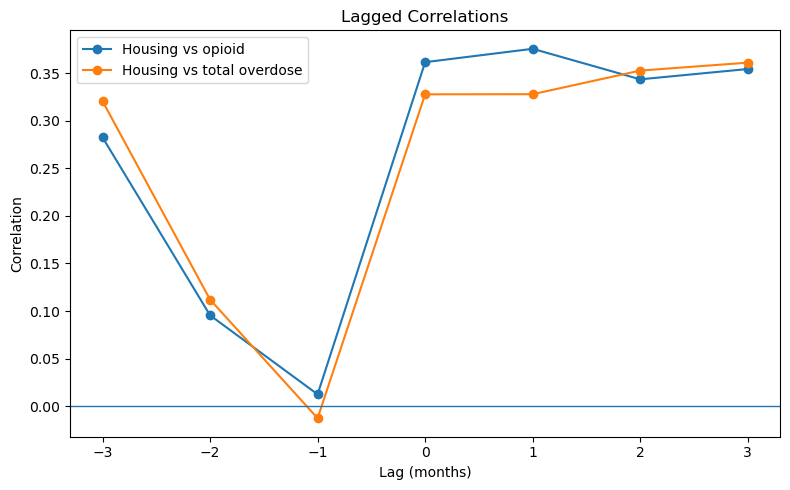

In [36]:
plt.figure()
plt.plot(lag_table["lag_months"], lag_table["corr_housing_opioid"], marker="o", label="Housing vs opioid")
plt.plot(lag_table["lag_months"], lag_table["corr_housing_overdose"], marker="o", label="Housing vs total overdose")
plt.axhline(0, linewidth=1)
plt.title("Lagged Correlations")
plt.xlabel("Lag (months)")
plt.ylabel("Correlation")
plt.legend()
plt.tight_layout()
plt.show()

### Analysis 2: Time-Adjusted Regression of Overdose Deaths on Housing Prices

Because both housing prices and overdose deaths changed over time during 2020–2021, simple correlations may be influenced by shared time trends. To address this, we estimated regression models that included both housing prices and a linear time trend, with opioid deaths and total overdose deaths as the outcomes.

The results show that after controlling for time trend, the housing coefficients were small and not statistically significant. For opioid deaths, the housing coefficient was -0.000080 with p was 0.316; for total overdose deaths, the coefficient was -0.000122 with p was 0.210. Although both models had high R² values, this mainly reflects the strong time trend in the data rather than an independent effect of housing prices. Overall, after accounting for time trend, we do not find strong evidence of a stable relationship between housing prices and overdose mortality.

In [37]:
df["t"] = np.arange(len(df), dtype=float)
df.head()

m_opioid = smf.ols("opioid_deaths ~ housing_zestimate_mean + t", data=df).fit()
m_overdose = smf.ols("overdose_deaths ~ housing_zestimate_mean + t", data=df).fit()

summary_table = pd.DataFrame({
    "model": ["opioid_deaths ~ housing + t", "overdose_deaths ~ housing + t"],
    "beta_housing": [
        m_opioid.params["housing_zestimate_mean"],
        m_overdose.params["housing_zestimate_mean"]
    ],
    "p_housing": [
        m_opioid.pvalues["housing_zestimate_mean"],
        m_overdose.pvalues["housing_zestimate_mean"]
    ],
    "r2": [m_opioid.rsquared, m_overdose.rsquared],
    "n": [int(m_opioid.nobs), int(m_overdose.nobs)]
})

summary_table

,model,beta_housing,p_housing,r2,n
0,opioid_deaths ~ housing + t,-0.000101,0.263226,0.978281,14
1,overdose_deaths ~ housing + t,-0.000122,0.209631,0.977007,12


Because both housing prices and overdose deaths changed over time during 2020–2021, simple correlations may be influenced by shared time trends. To address this, we estimated regression models that included both housing prices and a linear time trend, with opioid deaths and total overdose deaths as the outcomes.

The results show that after controlling for time trend, the housing coefficients were small and not statistically significant. For opioid deaths, the housing coefficient was -0.000080 with p = 0.316; for total overdose deaths, the coefficient was -0.000122 with p = 0.210. Although both models had high R² values, this mainly reflects the strong time trend in the data rather than an independent effect of housing prices. Overall, after accounting for time trend, we do not find strong evidence of a stable relationship between housing prices and overdose mortality.

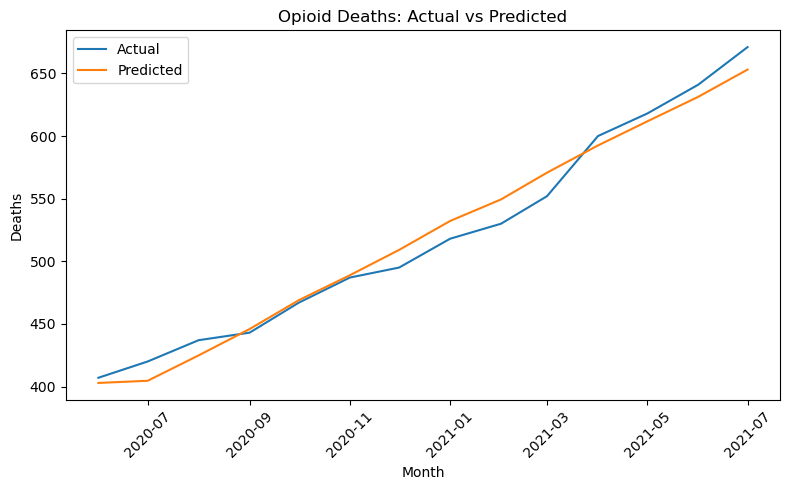

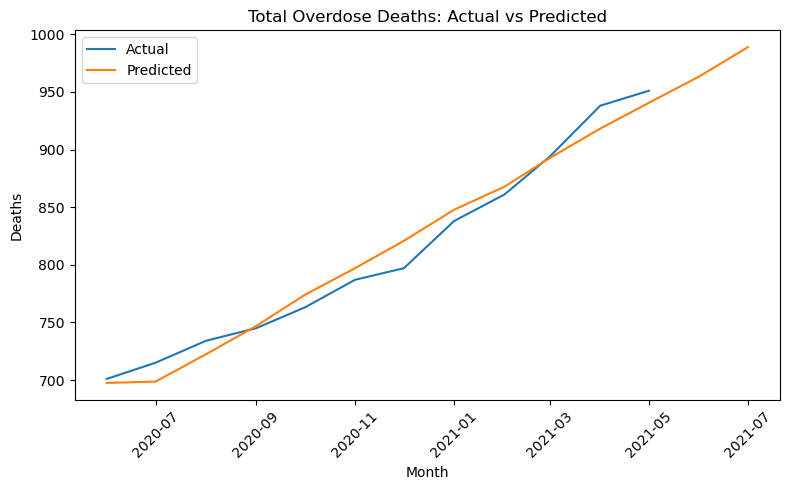

In [38]:
df["opioid_pred"] = m_opioid.predict(df)
df["overdose_pred"] = m_overdose.predict(df)

plt.figure()
plt.plot(df["year_month"], df["opioid_deaths"], label="Actual")
plt.plot(df["year_month"], df["opioid_pred"], label="Predicted")
plt.title("Opioid Deaths: Actual vs Predicted")
plt.xlabel("Month")
plt.ylabel("Deaths")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df["year_month"], df["overdose_deaths"], label="Actual")
plt.plot(df["year_month"], df["overdose_pred"], label="Predicted")
plt.title("Total Overdose Deaths: Actual vs Predicted")
plt.xlabel("Month")
plt.ylabel("Deaths")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Robustness Check: Scaling and Standardized Effect Sizes

As a robustness check, we standardized housing prices and the two mortality measures, and then re-estimated the same regression models. This was helpful because housing prices and death counts are measured on very different scales, and standardization makes the coefficients easier to compare.

The standardized models produced results that were very similar to the original regressions. The housing coefficients remained negative, but they were small and not statistically significant. For opioid deaths, the standardized coefficient was -0.061 and the p-value was 0.316; for total overdose deaths, the standardized coefficient was -0.074 and the p-value was 0.210. Both models still had high R² values, but this mainly reflects the strong time trend in the data rather than a clear independent effect of housing prices.

Overall, the robustness check supports the same conclusion as before: the data show some descriptive co-movement, but after accounting for time trend, there is no strong evidence of a stable and significant relationship between housing prices and overdose mortality.

In [39]:
def zscore(x):
    return (x - x.mean()) / x.std(ddof=0)

df["z_housing"] = zscore(df["housing_zestimate_mean"])
df["z_opioid"] = zscore(df["opioid_deaths"])
df["z_overdose"] = zscore(df["overdose_deaths"])
df["t"] = np.arange(len(df), dtype=float)

print(df[["z_housing", "z_opioid", "z_overdose", "t"]].head())
m_std_opioid = smf.ols("z_opioid ~ z_housing + t", data=df).fit()
m_std_overdose = smf.ols("z_overdose ~ z_housing + t", data=df).fit()

robust_table = pd.DataFrame({
    "model": ["z_opioid ~ z_housing + t", "z_overdose ~ z_housing + t"],
    "beta_z_housing": [
        m_std_opioid.params["z_housing"],
        m_std_overdose.params["z_housing"]
    ],
    "p_z_housing": [
        m_std_opioid.pvalues["z_housing"],
        m_std_overdose.pvalues["z_housing"]
    ],
    "r2": [m_std_opioid.rsquared, m_std_overdose.rsquared],
    "n": [int(m_std_opioid.nobs), int(m_std_overdose.nobs)]
})

robust_table

   z_housing  z_opioid  z_overdose    t
0  -3.502933 -1.379285   -1.334735  0.0
1   0.491686 -1.221206   -1.163823  1.0
2   0.573411 -1.014487   -0.931873  2.0
3   0.489483 -0.941527   -0.797585  3.0
4  -0.025238 -0.649688   -0.577842  4.0


,model,beta_z_housing,p_z_housing,r2,n
0,z_opioid ~ z_housing + t,-0.057574,0.263226,0.978281,14
1,z_overdose ~ z_housing + t,-0.070044,0.209631,0.977007,12


## Ethics

Our project uses aggregated, publicly available data sources: a housing market dataset  and CDC provisional overdose death counts. Because the overdose data are reported at an aggregate level (by month and geography), our analysis does not attempt to identify individuals and does not involve personally identifiable information.

There are still important ethical considerations. Overdose mortality is a sensitive topic, and results can be misinterpreted or stigmatize communities if presented carelessly. We therefore frame our findings as descriptive associations, avoid causal claims, and explicitly acknowledge that many unobserved confounders (economic conditions, policy changes, healthcare access, reporting artifacts, and pandemic-era disruptions) may explain observed patterns.

We also note limitations and potential biases in the data sources. Provisional death counts may be revised, and reporting practices can vary across time and jurisdictions. Housing estimates such as Zestimate are model-based and may not perfectly represent transaction prices. To reduce the risk of misleading conclusions, we transparently document cleaning steps, report uncertainty where appropriate, and emphasize that the analysis is intended for exploratory insight rather than policy prescription.

## Discussion and Conclusion

This study examined whether changes in housing prices in the Portland metropolitan area were associated with changes in drug overdose deaths in Oregon during 2020–2021. To address this question, we aligned monthly Zillow Zestimate averages with monthly CDC measures of opioid overdose deaths and total drug overdose deaths, and then conducted an exploratory analysis using time-series plots, correlations, lagged correlations, and regression models with a time trend.

At the descriptive level, housing prices and overdose deaths appeared to increase together during part of the study period, and the raw correlations suggested a modest positive relationship. However, once a time trend was included in the regression models, this relationship became much weaker and in some cases largely disappeared. This suggests that the apparent association may have been driven mainly by shared movement over time rather than by a stable direct relationship. The lagged correlation analysis was also inconsistent, with the strength of the relationship changing across different month shifts, which further indicates that the pattern was not robust.

Overall, we did not find strong evidence of a stable contemporaneous relationship between housing prices and overdose mortality in this dataset. This finding should be interpreted in light of several important limitations. First, the study covers only a short time period, from 2020 to 2021. Second, the two datasets do not represent the same geographic unit: the housing data reflect the Portland metropolitan area, while the mortality data are reported for Oregon as a whole. Third, the analysis relies on aggregated monthly data and does not include important control variables such as unemployment, income, healthcare access, or policy changes. For these reasons, the results should not be interpreted as causal.

Overall, this project is best understood as an exploratory analysis that describes how two public datasets moved over time at a shared monthly scale, rather than as evidence that housing prices affect overdose deaths. Future work could improve on this analysis by extending the time period, adding relevant socioeconomic controls, and comparing multiple cities or regions using more rigorous time-series or panel-data methods. These steps would provide a stronger basis for evaluating the relationship between housing market conditions and public health outcomes.


## Reference

Bradford, A. C., & Bradford, W. D. (2020). The effect of evictions on accidental drug and alcohol mortality. Health Services Research, 55(1), 9–17.

Cano, M., & Oh, S. (2023). State-Level Homelessness and Drug Overdose Mortality: Evidence from US Panel Data. Drug and Alcohol Dependence, 250, 110910.

Fink, D. S., Schleimer, J. P., Keyes, K. M., Branas, C. C., Cerdá, M., Gruenwald, P., & Hasin, D. (2024). Social and economic determinants of drug overdose deaths: a systematic review of spatial relationships. Social Psychiatry and Psychiatric Epidemiology, 59(7), 1087–1112.

Yamamoto, A., Needleman, J., Gelberg, L., Kominski, G., Shoptaw, S., & Tsugawa, Y. (2019). Association between homelessness and opioid overdose and opioid-related hospital admissions/emergency department visits. Social Science & Medicine, 242, 112585.